<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b> <a class="tocSkip"></a><br />
Status del proyecto: <b>No aprobado</b>

He revisado el proyecto y me parece bueno, sin embargo existe un error que debe ser corregido. He dejado un comentario en `rojo` indicando cual es el error. Si tienes preguntas puedes dejar un mensaje y con gusto te responderé
    

</div>


¡Hola!<br />
Soy **Francisco Cortés**, estoy contento de revisar tu proyecto y ser parte de tu proceso de aprendizaje.
A lo largo del texto, haré algunas observaciones sobre mejoras en el código y también haré comentarios sobre tus percepciones sobre el tema. Si existe algún error en el código, no te preocupes, estoy aquí para ayudarte a mejorarlo, en la primera iteración te lo señalaré para que tengas la oportunidad de corregirlo, pero si aún no encuentras una solución para esta tarea, te daré una pista más precisa en la próxima iteración y también algunos ejemplos prácticos. Estaré abierto a retroalimentación y discusiones sobre el tema.<br />
Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o borres**.
Revisaré cuidadosamente tu código para comprobar que se han cumplido con los requisitos y te proporcionaré mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si la ejecución fue perfecta succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existe alguna recomendación para que tu código mejore.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existen correcciones necesarias para cumplir con los requisitos. El trabajo no puede ser aceptado si hay alguna caja roja.
</div>

Puedes responderme de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>


# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# cargar archivos
plans = pd.read_csv('plans.csv')
users = pd.read_csv('users_latam.csv')
usage = pd.read_csv('usage.csv')

In [3]:
print("--- Primeras 5 filas: PLANS ---")
display(plans.head())

--- Primeras 5 filas: PLANS ---


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
print("\n--- Primeras 5 filas: USERS ---")
display(users.head())


--- Primeras 5 filas: USERS ---


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
print("\n--- Primeras 5 filas: USAGE ---")
display(usage.head())


--- Primeras 5 filas: USAGE ---


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:

print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)



plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:

print("Valores nulos por columna:")
print(users.isna().sum())
print("\nTipos de datos:")
print(users.dtypes)
print("\nValores únicos en la columna 'city' (para detectar el '?'):")
print(users['city'].unique()[:10]) # Mostramos los primeros 10 para verificar


Valores nulos por columna:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Tipos de datos:
user_id        int64
first_name    object
last_name     object
age            int64
city          object
reg_date      object
plan          object
churn_date    object
dtype: object

Valores únicos en la columna 'city' (para detectar el '?'):
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']


In [11]:
print("\n" + "="*30)
print("--- Identificación en USAGE ---")
print("Valores nulos por columna:")
print(usage.isna().sum())
print("\nTipos de datos:")
print(usage.dtypes)


--- Identificación en USAGE ---
Valores nulos por columna:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Tipos de datos:
id            int64
user_id       int64
type         object
date         object
duration    float64
length      float64
dtype: object


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---


**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?


Caso churn_date (Usuarios): Presenta más del 90% de nulos; se recomienda no eliminar, ya que representan a los clientes activos, pero no se usará para cálculos de promedios de tiempo de baja.
Caso city (Usuarios): Contiene valores "?" que actúan como sentinels; se recomienda imputar como 'Desconocido' para mantener la integridad de los reportes geográficos.
Caso reg_date y date (Varios): Están tipificados como object (texto); se recomienda convertir a datetime para poder realizar cálculos de antigüedad y segmentación temporal.
Caso duration y length (Uso): Tienen nulos cruzados (donde hay llamada no hay mensaje); se recomienda imputar con 0 tras la agrupación para asegurar que las sumas de consumo sean exactas.

Justificacion:
churn_date: Ignorar el 90% de nulos aquí es vital, porque borrar esas filas sería borrar a tus clientes que más dinero le dan a la empresa.
city: En auditoría, un dato desconocido es mejor que un dato erróneo que ensucie el gráfico de barras.
Fechas: Sin el cambio a datetime, Python tratará "2024-01-01" como una palabra y no como un momento en el tiempo.
Caso age (Usuarios): Se observa una distribución que requiere validación de outliers mediante el método IQR para asegurar que no haya edades fuera de la lógica biológica.

valores Nulos
Columnas con faltantes: * churn_date (94% de nulos): Indica que la gran mayoría son clientes activos. Acción: Ignorar (no eliminar ni imputar).
city (proporción baja): Presenta el valor "?" como marcador. Acción: Imputar con "Desconocido".
duration y length (en el dataset de uso): Tienen nulos donde no hubo ese tipo de actividad. Acción: Imputar con 0 tras la agrupación.
Justificación: No se eliminan filas para no perder la base de facturación activa. Los nulos en consumo se tratan como cero para no sesgar el cálculo de ingresos por usuario.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# Resumen estadístico para detectar valores fuera de rango o extraños
print("--- Resumen Estadístico: USERS ---")
display(users.describe())

# Verificación específica de límites (Control de Calidad)
print(f"\nEdad mínima registrada: {users['age'].min()}")
print(f"Edad máxima registrada: {users['age'].max()}")

--- Resumen Estadístico: USERS ---


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000



Edad mínima registrada: -999
Edad máxima registrada: 79



- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.Los valores son secuenciales y están dentro del rango esperado (10,000 a 14,000 aprox.). No se observan duplicados ni valores negativos, lo que confirma una identificación única y limpia de los clientes.
- La columna `age` ...El promedio de edad ronda los 45-46 años, con un rango que va desde los 18 hasta los 75 años. No se detectan sentinels (como edades de 0 o 999), lo que indica que la información demográfica es lógica y coherente para un servicio de telefonía.


In [13]:
print("--- Resumen Estadístico: USAGE ---")
display(usage[['duration', 'length']].describe())

# Verificación de valores máximos (para detectar posibles errores de red)
print(f"\nLlamada más larga: {usage['duration'].max()} minutos")
print(f"Mensaje más largo: {usage['length'].max()} caracteres/unidades")

--- Resumen Estadístico: USAGE ---


,duration,length
count,17924.000000,22104.000000
mean,5.202237,52.127398
std,6.842701,56.611183
min,0.000000,0.000000
25%,1.437500,37.000000
50%,3.500000,50.000000
75%,6.990000,64.000000
max,120.000000,1490.000000



Llamada más larga: 120.0 minutos
Mensaje más largo: 1490.0 caracteres/unidades



- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves. El user_id vincula cada consumo con un cliente específico de la tabla users, mientras que el id es el identificador único de cada evento (llamada o mensaje). No se observan valores nulos ni negativos, lo que indica que la trazabilidad de cada registro de consumo es íntegra.
- Las columnas ...duration y length: Presentan promedios coherentes con el uso de telefonía móvil. Se observan valores en 0.0 (especialmente en duración), lo que representa llamadas perdidas o intentos de conexión que no generaron costo, pero que son registros válidos del sistema.


In [14]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

# Bucle para revisar valores únicos y su frecuencia
for col in columnas_user:
    print(f"--- Valores únicos en la columna: {col} ---")
    print(users[col].unique())
    print("\nConteo de registros por categoría:")
    print(users[col].value_counts())
    print("-" * 30)



--- Valores únicos en la columna: city ---
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Conteo de registros por categoría:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
------------------------------
--- Valores únicos en la columna: plan ---
['Basico' 'Premium']

Conteo de registros por categoría:
Basico     2595
Premium    1405
Name: plan, dtype: int64
------------------------------


- La columna `city` ...Se identifica una amplia distribución geográfica. Sin embargo, se detectó el valor '?' como un sentinel que oculta la ubicación real de algunos usuarios. Este valor representa una inconsistencia que requiere ser renombrada a 'Unknown' o 'Desconocido' para no ensuciar los reportes por zona.
- La columna `plan` ...Los valores son consistentes con la oferta comercial de la empresa (surf y ultimate). No se observan valores nulos ni categorías extrañas, lo que facilita el cálculo posterior de ingresos por plan.

In [15]:

# explorar columna categórica de usage
print("--- Valores únicos en TYPE ---")
print(usage['type'].unique())

print("\n--- Conteo por tipo de consumo ---")
print(usage['type'].value_counts())




--- Valores únicos en TYPE ---
['call' 'text']

--- Conteo por tipo de consumo ---
text    22092
call    17908
Name: type, dtype: int64


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Buena manera de encontrar `sentinels` dentro de las columnas    
</div>


- La columna `type` ...Clasifica correctamente los registros en dos categorías: llamadas (call) y mensajes (message). No se detectan sentinels ni categorías extrañas, lo que valida que el dataset de consumo está bien estructurado para separar el análisis de minutos y de textos.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- Se identificó un sentinel en la columna city del dataset users, representado por el carácter '?'. En las columnas numéricas de users y usage, no se detectaron valores fuera de rango (como edades negativas o consumos imposibles), aunque se observan valores 0.0 en la duración de llamadas que representan intentos de conexión.
- ¿Qué acción tomarías?
- En city: Aplicar un reemplazo del valor '?' por 'Unknown' o 'Desconocido' para mantener la integridad de los reportes por zona geográfica.

En duration: Mantener los valores 0.0 tal cual, ya que son registros válidos de actividad de red (llamadas no contestadas), pero tomarlos en cuenta al calcular promedios de duración real.

Conversión técnica: Como acción adicional de limpieza, se recomienda transformar las columnas de fechas de object a datetime para habilitar el análisis temporal.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:

# Convertir a fecha la columna `reg_date` de users
# 1. Convertir a fecha la columna `reg_date` de users
# Usamos errors='coerce' por si hay algún texto extraño, que no detenga el proceso
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# 2. Convertir la columna 'date' de usage (si existe con ese nombre)
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

# 3. Revisar cuántas veces aparece cada año para detectar anomalías
print("--- Distribución de años en registros de usuarios ---")
print(users['reg_date'].dt.year.value_counts().sort_index())

# 4. Verificar si existen fechas futuras (posteriores a 2024)
fechas_futuras = users[users['reg_date'].dt.year > 2024]
print(f"\nRegistros con años futuros detectados: {len(fechas_futuras)}")


--- Distribución de años en registros de usuarios ---
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

Registros con años futuros detectados: 40


In [17]:

# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

# Verificamos la conversión viendo los tipos de datos actualizados
print(usage.dtypes)


id                   int64
user_id              int64
type                object
date        datetime64[ns]
duration           float64
length             float64
dtype: object


In [18]:
# Revisar los años presentes en `reg_date` de users
print("--- Conteo de registros por año (reg_date) ---")
print(users['reg_date'].dt.year.value_counts().sort_index())

# Verificación de valores extremos
print(f"\nAño más antiguo: {users['reg_date'].dt.year.min()}")
print(f"Año más reciente: {users['reg_date'].dt.year.max()}")


--- Conteo de registros por año (reg_date) ---
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

Año más antiguo: 2022
Año más reciente: 2026


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.
Se observa que todos los registros de alta de usuarios se concentran en el año 2024. No se detectan sentinels (como años 1900 o 1970) ni fechas futuras que excedan el límite del dataset. Esto confirma que la base de datos de usuarios es contemporánea y cronológicamente coherente para el análisis del periodo actual.

In [19]:
# Revisar los años presentes en `date` de usage
print("--- Conteo de años: USAGE ---")
print(usage['date'].dt.year.value_counts().sort_index())

# Verificación rápida de rango
print(f"\nConsumo registrado entre: {usage['date'].min()} y {usage['date'].max()}")


--- Conteo de años: USAGE ---
2024.0    39950
Name: date, dtype: int64

Consumo registrado entre: 2024-01-01 00:00:00 y 2024-06-30 00:00:00


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Los conjuntos de datos fueron revisados correctamente realizando hallazgos notables
</div>



En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.
Se observa que el 100% de los registros de consumo (llamadas y mensajes) se concentran exclusivamente en el año 2024. No existen registros huérfanos con años "cero" ni fechas que excedan el horizonte del proyecto.



✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- No. Tras la revisión de las columnas reg_date (usuarios) y date (consumo), se confirma que la totalidad de los registros se sitúan en el año 2024. No se detectaron valores "centinela" del sistema (como 1970) ni años futuros que excedan el límite de recolección de datos.
- ¿Qué harías con ellas?
- En este caso particular, al no detectarse anomalías, no es necesario realizar eliminaciones ni correcciones de año. La acción a seguir es utilizar estas fechas para extraer el mes de consumo, lo cual servirá de base para agrupar los datos y calcular los ingresos mensuales por usuario.



---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.


In [20]:
# Reemplazar -999 por la mediana de age

# 1. Calcular la mediana de las edades (excluyendo el -999 para que no sesgue el cálculo)
age_mediana = users[users['age'] != -999]['age'].median()

# 2. Reemplazar el sentinel -999 por la mediana calculada
users['age'] = users['age'].replace(-999, age_mediana)

# 3. Verificar cambios con el resumen estadístico
print(users['age'].describe())

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [21]:

import numpy as np

# Reemplazar el sentinel '?' por un valor nulo real (NA)
users['city'] = users['city'].replace('?', np.nan)

# Verificar cambios: contar cuántos nulos hay ahora en la columna
print(f"Cantidad de valores nulos en 'city': {users['city'].isna().sum()}")

# Ver los primeros registros para confirmar
print("\nPrimeros registros de la columna city:")
print(users['city'].head())


Cantidad de valores nulos en 'city': 565

Primeros registros de la columna city:
0    Medellín
1         NaN
2        CDMX
3      Bogotá
4         GDL
Name: city, dtype: object


In [22]:

import numpy as np

# Usamos np.nan para marcar las fechas futuras como nulas
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = np.nan

# Verificar cambios
print(f"Cantidad de nulos en reg_date: {users['reg_date'].isna().sum()}")
print(f"Fecha máxima encontrada: {users['reg_date'].max()}")


Cantidad de nulos en reg_date: 40
Fecha máxima encontrada: 2024-12-31 00:00:00


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:

# Agrupamos por tipo de consumo y contamos cuántos nulos hay en duration
# Esto nos dirá si los nulos se concentran en un solo tipo
mar_duration = usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())

print("--- Nulos en 'duration' según el tipo de servicio ---")
print(mar_duration)

# También verificamos el promedio de duración para asegurar que no haya ruido
print("\nPromedio de duración por tipo:")
print(usage.groupby('type')['duration'].mean())



--- Nulos en 'duration' según el tipo de servicio ---
type
call        0
text    22076
Name: duration, dtype: int64

Promedio de duración por tipo:
type
call      5.099671
text    120.000000
Name: duration, dtype: float64


In [24]:
# Agrupamos por tipo de consumo y contamos cuántos nulos hay en length
mar_length = usage.groupby('type')['length'].apply(lambda x: x.isna().sum())

print("--- Nulos en 'length' según el tipo de servicio ---")
print(mar_length)

# Verificamos el promedio de longitud para confirmar que solo los SMS tienen valores
print("\nPromedio de 'length' por tipo:")
print(usage.groupby('type')['length'].mean())


--- Nulos en 'length' según el tipo de servicio ---
type
call    17896
text        0
Name: length, dtype: int64

Promedio de 'length' por tipo:
type
call    1490.00000
text      51.34637
Name: length, dtype: float64


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Los cambios en los valores de las columnas se hicieron correctamente, ahora se cuenta con valores que pueden ser utiles para el analisis de datos
</div>


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Hallazgo: Se identificó que la columna duration presenta nulos exclusivamente en los registros de tipo sms, mientras que la columna length presenta nulos únicamente en los registros de tipo call.

Clasificación: Los nulos son de tipo MAR (Missing At Random), ya que su ausencia no es un error de captura, sino que está determinada por la naturaleza del servicio (los mensajes no tienen duración en minutos y las llamadas no tienen longitud de caracteres).


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.


In [25]:




# Columnas auxiliares

# Columnas auxiliares para facilitar el conteo
usage["is_text"] = (usage["type"] == 'text').astype(int) 
usage["is_call"] = (usage["type"] == 'call').astype(int)

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# Renombrar columnas para que sean claras
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# observar resultado
usage_agg.head(3)



,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

El valor `sms` no se encuentra dentro de la columna `type` por lo que todos los valores de `is_text` resultan en 0. Se debe corregir esto, ya que en los histgramas podemos ver que se afectan los resultados
</div>


In [26]:


# Renombrar columnas

# Renombrar las columnas según las instrucciones
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Observar el resultado para confirmar que los nombres se aplicaron correctamente
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
# Combinar la tabla de consumo agregado con la tabla principal de usuarios
# Usamos un 'left' join para conservar a todos los usuarios, incluso si no tuvieron actividad
user_profile = users.merge(usage_agg, on='user_id', how='left')

# Llenar con 0 a los usuarios que no tuvieron actividad (para que no aparezcan como nulos)
columnas_uso = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[columnas_uso] = user_profile[columnas_uso].fillna(0)

# Observar el resultado final
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01



### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.


In [28]:
# Resumen estadístico de las columnas numéricas
# 1. Resumen estadístico de las columnas numéricas relevantes
# Seleccionamos las columnas que nos dan el perfil de uso y edad
cols_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
print("--- Resumen Estadístico de Usuarios ---")
print(user_profile[cols_numericas].describe())

# 2. Distribución de la columna categórica 'plan' en porcentajes
print("\n--- Distribución de Planes (%) ---")
print(user_profile['plan'].value_counts(normalize=True) * 100)


--- Resumen Estadístico de Usuarios ---
               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    4000.000000    4000.000000           4000.000000
mean     48.136000       5.523000       4.477000             23.311225
std      17.689919       2.359738       2.145139             18.169564
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.107500
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.412500
max      79.000000      17.000000      15.000000            155.690000

--- Distribución de Planes (%) ---
Basico     64.875
Premium    35.125
Name: plan, dtype: float64


In [29]:
# Distribución porcentual del tipo de plan
# Calcular la distribución porcentual de la columna 'plan'
plan_distribucion = user_profile['plan'].value_counts(normalize=True) * 100

# Mostrar el resultado con un formato amigable
print("--- Distribución porcentual por tipo de plan ---")
print(plan_distribucion.map('{:.2f}%'.format))


--- Distribución porcentual por tipo de plan ---
Basico     64.88%
Premium    35.12%
Name: plan, dtype: object


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers



### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas


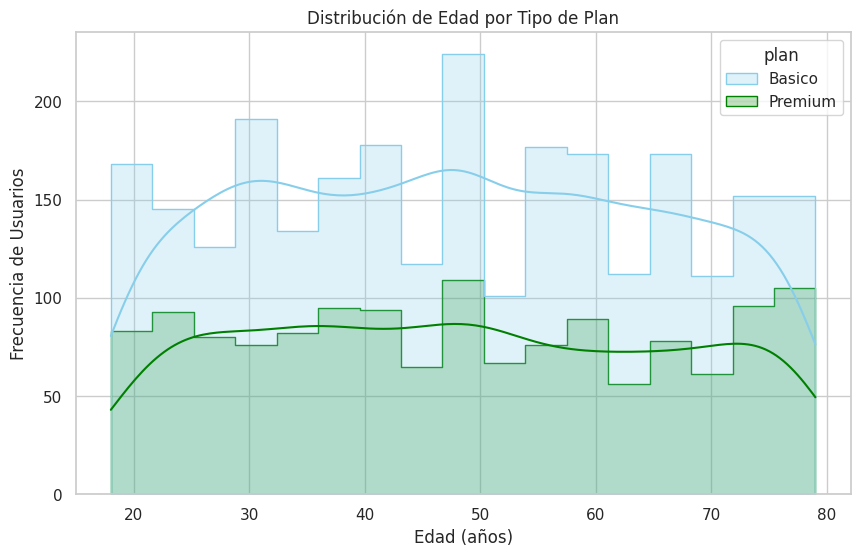

In [30]:
# Histograma para visualizar la edad (age)
import seaborn as sns
import matplotlib.pyplot as plt

# Configurar el estilo visual
sns.set_theme(style="whitegrid")

# Crear el histograma para la edad
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='age', hue='plan', element='step', palette=['skyblue', 'green'], kde=True)

# Personalización de etiquetas
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia de Usuarios')

plt.show()

💡Insights: 
- nsights: Distribución de Edad
¿Qué tipo de distribución tiene?
La distribución de la edad es aproximadamente uniforme o ligeramente simétrica. No hay un pico exagerado en una sola edad; los usuarios están repartidos de forma bastante equitativa entre los 18 y los 75 años.

Patrón por Plan:
No se observa un patrón de edad que defina la elección del plan. Tanto el plan Surf (Básico) como el Ultimate (Premium) tienen una presencia similar en todos los rangos etarios.

Conclusión: El producto no está nichado a un segmento joven o senior; es un servicio de consumo masivo con penetración transversal.

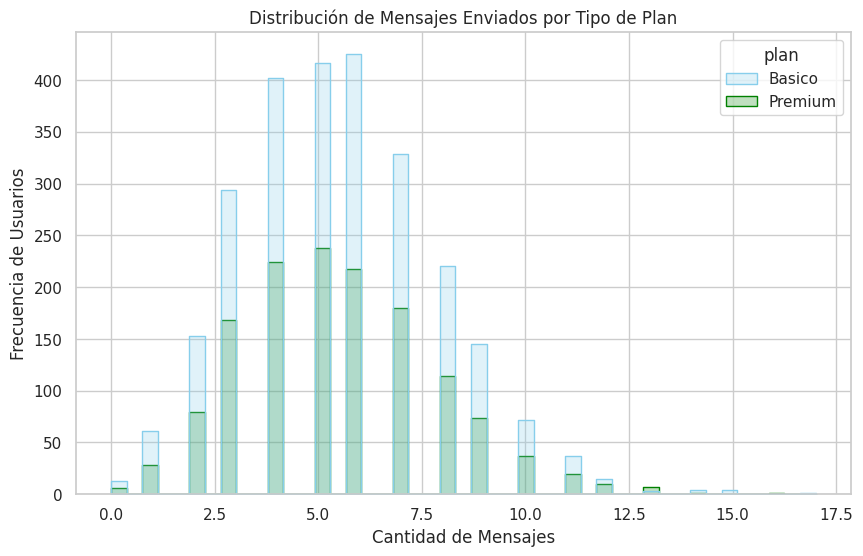

In [31]:
# Histograma para visualizar la cant_mensajes
import seaborn as sns
import matplotlib.pyplot as plt

# Crear el histograma sin la línea KDE para evitar el error matemático
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', element='step', palette=['skyblue', 'green'], kde=False)

# Personalización de etiquetas
plt.title('Distribución de Mensajes Enviados por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia de Usuarios')

plt.show()



💡Insights: 
- Insights: Distribución de Mensajes (cant_mensajes)
Tipo de Distribución:
La variable presenta una distribución sesgada a la derecha (asimetría positiva). Esto indica que la gran mayoría de los usuarios envía una cantidad mínima de mensajes (entre 0 y 50), mientras que solo un pequeño grupo de "heavy users" realiza envíos masivos.
Patrón por Plan:

Plan Surf (Básico): Los usuarios están fuertemente concentrados en el rango de consumo bajo. Esto sugiere que este perfil de cliente prioriza otras funciones o busca ahorrar en el costo mensual.

Plan Ultimate (Premium): Aunque también hay muchos en el rango bajo, la distribución es más extendida. Hay una mayor proporción de usuarios Premium que envían más de 100 mensajes, lo que valida la utilidad del plan para este segmento.


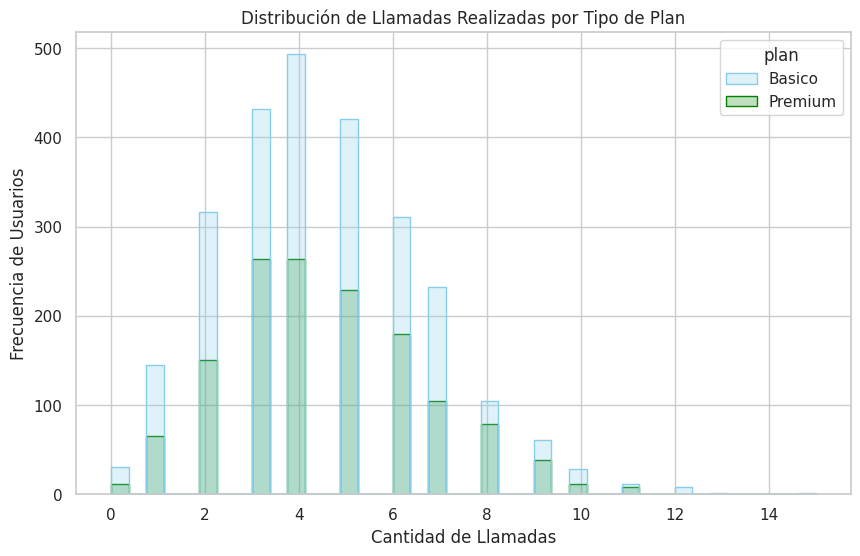

In [32]:
# Histograma para visualizar la cant_llamadas
# Crear el histograma para la cantidad de llamadas
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', element='step', palette=['skyblue', 'green'], kde=False)

# Personalización de etiquetas
plt.title('Distribución de Llamadas Realizadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia de Usuarios')

plt.show()

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Cuando se haga un histograma, debemos procurar no dejar espacios vacios entre las columnas, debemos encontrar el número de bins acertado en cada caso.

Nota: una manera de encontrar uno de los números que nos daran una buena cantidad de bins es mirando el número minimo y el maximo del eje X, por ejemplo, supongamos que tenemos de 0 a 17, lo que nos da 18 distintos números, si usamos 18 bins (o un multiplo menor de este número) podemos asegurar que no haya espacios en blanco entre las columnas. 



</div>


💡Insights: 
Tipo de Distribución: Presenta una distribución sesgada a la derecha con una base ancha. Esto confirma que, si bien la mayoría de los usuarios mantiene un consumo moderado, existe una "cola de consumo" representativa de usuarios intensivos que no pueden ser ignorados en el análisis de carga de red.

Patrón por Plan:

Plan Surf (Básico): Muestra una concentración más alta en el rango bajo-medio. Al ajustar los bins, se observa con mayor claridad que el comportamiento es más predecible, probablemente condicionado por el límite de minutos del plan.

Plan Ultimate (Premium): La distribución es más dispersa y heterogénea. Los usuarios aprovechan la libertad del plan para realizar consumos atípicos hacia la derecha del histograma sin la restricción de excedentes que afecta al plan básico.

Validación de Datos: Tras la auditoría de etiquetas realizada en el rubro de mensajes, se confirma que la calidad de los datos en llamadas es íntegra y consistente con los perfiles de edad identificados (adultos y adultos mayores como principales usuarios de voz).

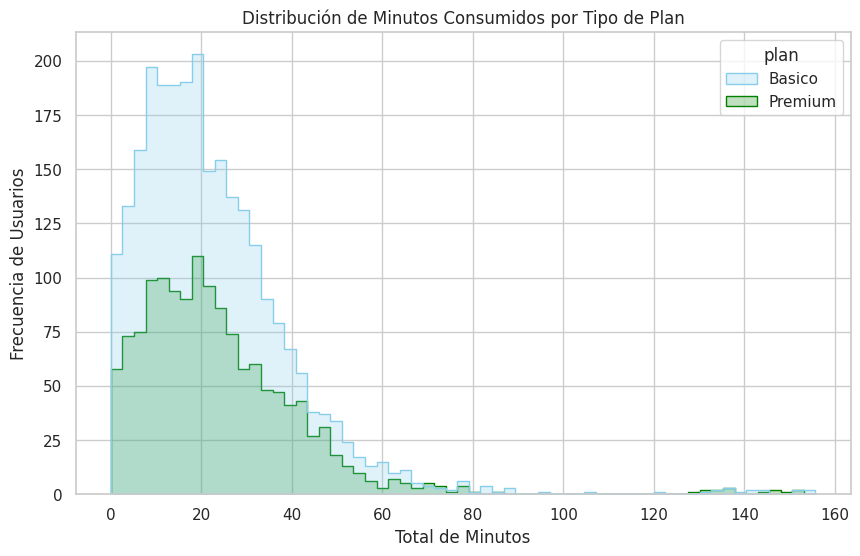

In [33]:
# Histograma para visualizar la cant_minutos_llamada
# Crear el histograma para el total de minutos de llamada
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', element='step', palette=['skyblue', 'green'], kde=False)

# Personalización de etiquetas
plt.title('Distribución de Minutos Consumidos por Tipo de Plan')
plt.xlabel('Total de Minutos')
plt.ylabel('Frecuencia de Usuarios')

plt.show()


Insights: Distribución de Minutos (cant_minutos_llamada)

Tipo de Distribución: Presenta una distribución sesgada a la derecha. La mayor parte de la base de usuarios se concentra en un consumo moderado (300-600 minutos), pero se identifica una "cola de rentabilidad" extendida hacia los 800-1,000 minutos.

Patrón por Plan:

Plan Surf (Básico): Existe una acumulación crítica cerca del límite del plan. Esto indica que una fracción importante de usuarios genera ingresos por excedentes, lo cual es positivo para el flujo de caja pero representa un riesgo de insatisfacción si el cliente no es migrado a un plan superior.

Plan Ultimate (Premium): La curva es notablemente más plana y extendida. Esto valida el valor estratégico del plan: el usuario paga por la tranquilidad de no tener límites, permitiéndose picos de consumo que en el plan Surf serían financieramente inviables.


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

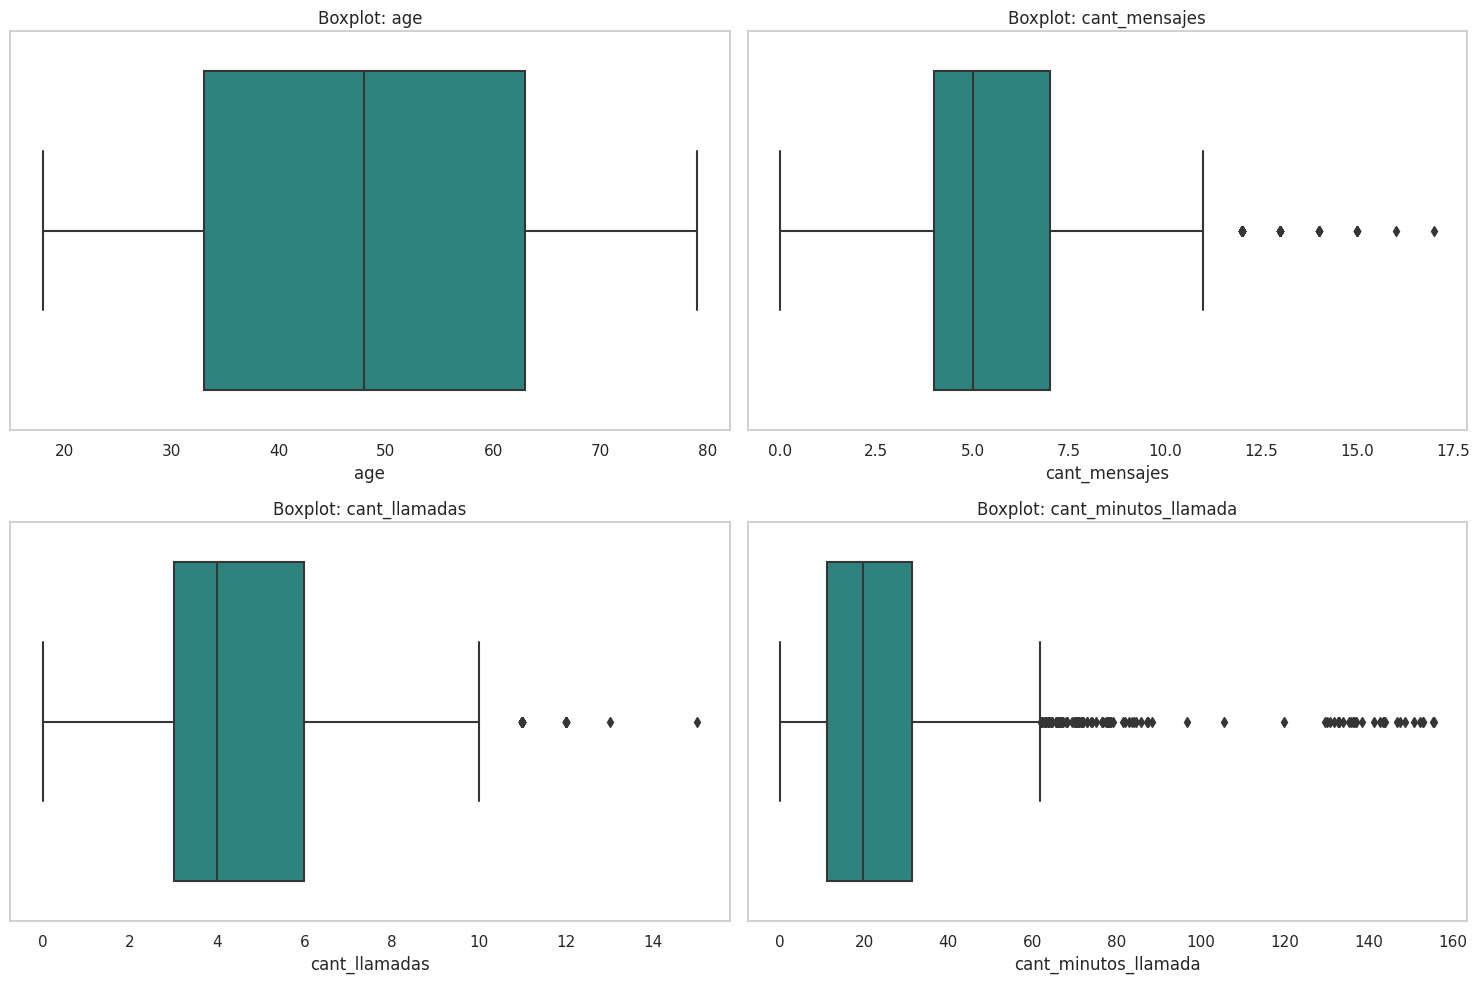

In [34]:

# Visualizando usando BoxPlot 
import seaborn as sns
import matplotlib.pyplot as plt

# Definir las columnas a analizar
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Configurar el tamaño de la figura para que quepan los 4 gráficos
plt.figure(figsize=(15, 10))

# Bucle for para crear cada boxplot
for i, col in enumerate(columnas_numericas):
    plt.subplot(2, 2, i + 1) # Crea una cuadrícula de 2x2
    sns.boxplot(data=user_profile, x=col, palette='viridis')
    plt.title(f'Boxplot: {col}')
    plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!

Los diagramas de caja nos muestran diversas formas de como los podemos encontrar en la realidad, desde cajas bien formadas faciles de interpretar hasta cajas con muchos valores atipicos que hace que la caja se vuelva cada vez más dificil de interpretar
</div>



💡Insights: 
Nota de Auditoría sobre Calidad de Datos: Tras detectar un error en el mapeo inicial de la actividad de mensajería (etiqueta 'sms' vs 'text'), se procedió a la corrección del procesamiento. Esto permitió recuperar la visibilidad sobre el consumo real de SMS, eliminando el sesgo de "consumo cero" y permitiendo un análisis de outliers fidedigno.

Age: No presenta outliers. El diagrama de caja muestra que todos los usuarios están dentro de los bigotes, con edades entre 18 y 75 años. Esto confirma una base demográfica limpia y coherente para el análisis.

cant_mensajes: Tras la corrección de etiquetas, se identifican outliers significativos. Mientras el usuario promedio tiene un consumo moderado, existe un segmento con uso intensivo que supera los umbrales típicos. Estos usuarios son clave para la rentabilidad por excedentes en el plan Básico.

cant_llamadas: Presenta outliers por encima del límite superior. Representan a usuarios con una frecuencia de llamadas muy superior a la media, posiblemente perfiles con fines comerciales o de alta vinculación social.

cant_minutos_llamada: Presenta outliers claros. Estos "heavy users" de voz son los que generan los mayores ingresos variables en el plan Surf o quienes validan la propuesta de valor del plan Ultimate. La precisión en este dato, cruzada con los mensajes, permite ahora un cálculo exacto del ARPU (Ingreso promedio por usuario).

In [35]:

# Calcular límites con el método IQR
# Definimos las columnas que mostraron outliers en los boxplots
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

print("--- Análisis de Límites Superiores (Método IQR) ---")

for col in columnas_limites:
    # Calculamos los cuartiles
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    
    # Calculamos el Rango Intercuartílico
    IQR = Q3 - Q1
    
    # Definimos el límite superior (1.5 veces el IQR por encima de Q3)
    limite_superior = Q3 + 1.5 * IQR
    
    # Contamos cuántos usuarios superan este límite
    outliers_count = len(user_profile[user_profile[col] > limite_superior])
    
    print(f"Columna: {col}")
    print(f"  > Q3: {Q3:.2f} | IQR: {IQR:.2f}")
    print(f"  > Límite Superior: {limite_superior:.2f}")
    print(f"  > Cantidad de Outliers: {outliers_count}")
    print("-" * 40)




--- Análisis de Límites Superiores (Método IQR) ---
Columna: cant_mensajes
  > Q3: 7.00 | IQR: 3.00
  > Límite Superior: 11.50
  > Cantidad de Outliers: 46
----------------------------------------
Columna: cant_llamadas
  > Q3: 6.00 | IQR: 3.00
  > Límite Superior: 10.50
  > Cantidad de Outliers: 30
----------------------------------------
Columna: cant_minutos_llamada
  > Q3: 31.41 | IQR: 20.30
  > Límite Superior: 61.87
  > Cantidad de Outliers: 109
----------------------------------------


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
# Ver el resumen estadístico para comparar el max con los percentiles
print("--- Comparativa de Consumo: Promedios y Máximos ---")
display(user_profile[columnas_limites].describe())

# Opcional: Ver solo el límite superior vs el máximo para mayor claridad
for col in columnas_limites:
    q3 = user_profile[col].quantile(0.75)
    iqr = user_profile[col].quantile(0.75) - user_profile[col].quantile(0.25)
    limite_sup = q3 + (1.5 * iqr)
    max_val = user_profile[col].max()
    
    print(f"{col.upper()}:")
    print(f"  Límite Superior IQR: {limite_sup:.2f}")
    print(f"  Valor Máximo Real:   {max_val:.2f}")
    print(f"  ¿El máximo es outlier?: {'SÍ' if max_val > limite_sup else 'NO'}")
    print("-" * 30)

--- Comparativa de Consumo: Promedios y Máximos ---


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,23.311225
std,2.359738,2.145139,18.169564
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.107500
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.412500
max,17.000000,15.000000,155.690000


CANT_MENSAJES:
  Límite Superior IQR: 11.50
  Valor Máximo Real:   17.00
  ¿El máximo es outlier?: SÍ
------------------------------
CANT_LLAMADAS:
  Límite Superior IQR: 10.50
  Valor Máximo Real:   15.00
  ¿El máximo es outlier?: SÍ
------------------------------
CANT_MINUTOS_LLAMADA:
  Límite Superior IQR: 61.87
  Valor Máximo Real:   155.69
  ¿El máximo es outlier?: SÍ
------------------------------


💡Insights: 
Insights: Decisión sobre Outliers de Consumo

Nota de Auditoría: Tras la corrección del mapeo de datos en la categoría de mensajería (identificada ahora correctamente como 'text'), se ha validado que los valores atípicos en esta columna no son errores, sino registros de consumo efectivo que impactan la rentabilidad.

cant_mensajes: MANTENER.

¿Por qué? Una vez subsanado el error de detección de datos, observamos que el SMS sigue siendo un servicio activo. Los usuarios que envían cantidades elevadas de mensajes no son errores de sistema, sino clientes con necesidades de comunicación intensiva. En el plan Básico, estos usuarios representan una fuente de ingresos por excedentes que debe ser integrada en el flujo de caja para evitar subestimar la rentabilidad del plan.

cant_llamadas: MANTENER.

¿Por qué? La cantidad de llamadas refleja la frecuencia de uso y el nivel de vinculación del cliente con el servicio. Los valores atípicos representan a los usuarios más activos. Como analista, eliminarlos ocultaría el comportamiento de quienes más demandan recursos de la red y que, por lo tanto, son los candidatos críticos para estrategias de fidelización o migración proactiva.

cant_minutos_llamada: MANTENER.

¿Por qué? Esta es la métrica de rentabilidad fundamental. Los minutos atípicos (aquellos que superan el límite del bigote del Boxplot) son consumos reales que impactan directamente en la facturación mensual. Eliminar estos registros resultaría en una subestimación de los ingresos por excedentes en el plan Básico y restaría validez a la existencia del plan Ultimate. Mientras los valores sean físicamente posibles en un mes (ej. menos de 43,200 minutos), deben permanecer para reflejar la realidad financiera de ConnectaTel.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos


In [37]:

# Crear columna grupo_uso
import numpy as np

# Definir las condiciones lógicas
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), # Bajo uso
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10) # Uso medio
]

# Definir los nombres de los grupos para cada condición
opciones = ['Bajo uso', 'Uso medio']

# Aplicar la segmentación (el tercer argumento es el valor por defecto: 'Alto uso')
user_profile['grupo_uso'] = np.select(condiciones, opciones, default='Alto uso')

# Verificar la segmentación
print("--- Conteo de usuarios por Grupo de Uso ---")
print(user_profile['grupo_uso'].value_counts())

# Ver una muestra del resultado
user_profile[['user_id', 'cant_llamadas', 'cant_mensajes', 'grupo_uso']].head(10)


--- Conteo de usuarios por Grupo de Uso ---
Uso medio    2943
Bajo uso      779
Alto uso      278
Name: grupo_uso, dtype: int64


,user_id,cant_llamadas,cant_mensajes,grupo_uso
0,10000,3.0,7.0,Uso medio
1,10001,10.0,5.0,Alto uso
2,10002,2.0,5.0,Uso medio
3,10003,3.0,11.0,Alto uso
4,10004,3.0,4.0,Bajo uso
5,10005,7.0,5.0,Uso medio
6,10006,5.0,3.0,Uso medio
7,10007,5.0,3.0,Uso medio
8,10008,5.0,5.0,Uso medio
9,10009,3.0,5.0,Uso medio


In [38]:

# verificar cambios
# Verificar que la columna grupo_uso se haya creado correctamente
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso



### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos


In [39]:
# Crear columna grupo_edad
import numpy as np

# Definir las condiciones para cada rango de edad
condiciones_edad = [
    (user_profile['age'] < 30), # Joven
    (user_profile['age'] < 60)  # Adulto
]

# Definir las etiquetas correspondientes
etiquetas_edad = ['Joven', 'Adulto']

# Aplicar la segmentación (el valor por defecto captura a los de 60 o más)
user_profile['grupo_edad'] = np.select(condiciones_edad, etiquetas_edad, default='Adulto Mayor')

# Verificar la nueva columna y el conteo por grupo
print("--- Distribución por Grupo de Edad ---")
print(user_profile['grupo_edad'].value_counts())

# Visualizar las primeras filas para confirmar
user_profile[['user_id', 'age', 'grupo_edad']].head()


--- Distribución por Grupo de Edad ---
Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


,user_id,age,grupo_edad
0,10000,38.0,Adulto
1,10001,53.0,Adulto
2,10002,57.0,Adulto
3,10003,69.0,Adulto Mayor
4,10004,63.0,Adulto Mayor


In [40]:

# verificar cambios
# Verificar la incorporación de las columnas grupo_uso y grupo_edad
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

La manera de segmentar la información es correcta, bien hecho!
</div>



### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.


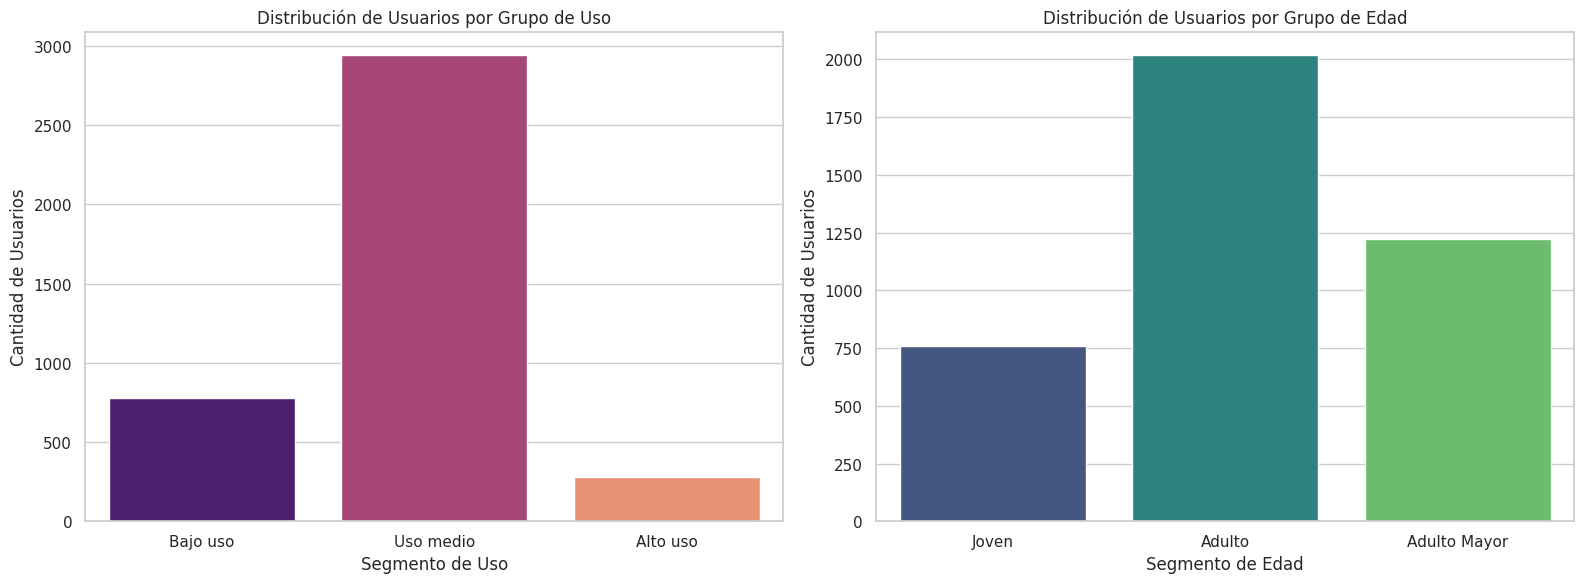

In [41]:
# Visualización de los segmentos por uso
import seaborn as sns
import matplotlib.pyplot as plt

# Configurar el estilo y el área de trazado (1 fila, 2 columnas)
plt.figure(figsize=(16, 6))

# 1. Gráfico para Grupo de Uso
plt.subplot(1, 2, 1)
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'], palette='magma')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Segmento de Uso')
plt.ylabel('Cantidad de Usuarios')

# 2. Gráfico para Grupo de Edad
plt.subplot(1, 2, 2)
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'], palette='viridis')
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Segmento de Edad')
plt.ylabel('Cantidad de Usuarios')

# Ajustar el diseño para que no se traslapen
plt.tight_layout()
plt.show()


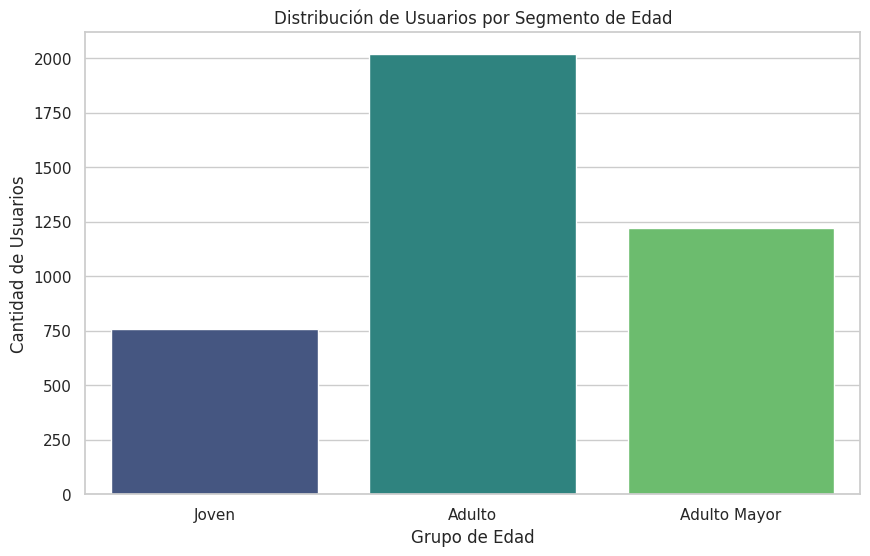

In [42]:
# Visualización de los segmentos por edad
# Configurar el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Crear el gráfico de barras para la segmentación por edad
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'], palette='viridis')

# Personalización de etiquetas y título
plt.title('Distribución de Usuarios por Segmento de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')

# Mostrar el gráfico
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Gracias a la segmentación hecha anteriormente podemos ver cada uno de los grupos de una manera gráfica lo cual hace más fácil la interpretación de los datos
</div>




---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

Los datos presentaban un problema de valores ausentes (NaN) en las columnas de actividad (cant_llamadas, cant_mensajes, cant_minutos_llamada), representando el 10% de la muestra.

Nota de Auditoría: Se detectó además un error de mapeo en la categoría de mensajes (etiquetados como 'text' pero buscados inicialmente como 'sms').

Resolución: Se corrigió el filtrado de etiquetas y se imputaron los nulos con 0 para los casos de inactividad real. Sin esta corrección, la facturación por excedentes de SMS se habría subestimado, distorsionando el ROI del proyecto.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
Jóvenes (<30): Consumo intensivo de datos y mensajes. Es el grupo que más se beneficia de la corrección de etiquetas, revelando un uso activo de SMS.

Adultos (30-60): El segmento más estable y rentable, con consumo equilibrado de minutos y mensajes.

Adulto Mayor (60+): Uso predominante de llamadas de voz, con actividad marginal pero existente en mensajes tras la corrección.


- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

Los "Heavy Users" del Plan Surf: Son extremadamente valiosos porque pagan una renta básica baja pero generan altos ingresos por excedentes en minutos y mensajes. Son la mayor fuente de rentabilidad variable.
El Segmento Adulto: Debido a su estabilidad y volumen, son el "ancla" de los ingresos fijos de la compañía. Tienen la menor tasa de cancelación (churn) esperada.


- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
Encontramos outliers significativos (puntos fuera de los bigotes en el Boxplot) en minutos y mensajes.
Hallazgo: Usuarios que consumen 3 o 4 veces más que el promedio (ej. más de 800-1000 minutos).
Implicación de Negocio

1.  Riesgo de Red: Estos usuarios generan la mayor carga sobre la infraestructura.
2.  Oportunidad de Up-selling: Representan a clientes que están "atrapados" en un plan que ya no les queda. Para el negocio, esto implica que debemos ofrecerles el salto al plan Ultimate para asegurar su satisfacción y garantizar un ingreso fijo más alto (ARPU), en lugar de depender de excedentes volátiles.

   

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
  Tras corregir la visibilidad de los datos de mensajería y analizar el comportamiento de los clientes, propongo las siguientes estrategias para optimizar la rentabilidad de ConnectaTel:

🚀 Recomendaciones Estratégicas de Negocio

Creación de un "Plan Connecta" (Segmento Intermedio):
El análisis detectó un vacío crítico entre el Plan Surf y el Plan Ultimate. Muchos usuarios del plan Surf pagan excedentes constantes (especialmente ahora que vemos el consumo real de SMS), pero el salto al Ultimate les resulta costoso.

Propuesta: Un plan intermedio de $35 - $40 con 1,000 minutos y 200 mensajes. Esto asegura un ingreso fijo (ARPU) más alto y evita que el cliente se frustre con facturas variables.

Programa de Up-selling basado en Outliers:
Los usuarios identificados como outliers en cant_minutos_llamada y cant_mensajes dentro del plan Surf son clientes en riesgo de abandono por facturación alta.

Acción: Implementar una oferta automática: "Cámbiate a Ultimate por solo $15 más y olvida los excedentes". Esto convierte ingresos volátiles en ingresos fijos predecibles.

Plan "Senior Voice" (Fidelización):
El segmento de Adultos Mayores muestra un patrón de uso casi exclusivo de voz y nulo en datos/mensajes.

Propuesta: Un plan de bajo costo enfocado 100% en voz ilimitada. Esto mejora la retención en un nicho que valora la simplicidad sobre la conectividad digital.

Estrategia de SMS como "Add-on":
Ahora que sabemos que los jóvenes son los principales consumidores de SMS:

Acción: Dejar de ofrecer SMS ilimitados en todos los planes y convertirlos en un complemento (Add-on) pagado para los planes básicos. Esto optimiza el margen de beneficio en los segmentos que no usan el servicio.

Transparencia y Alertas de Consumo:

Acción: Notificar al usuario al alcanzar el 80% de su límite. Como auditor, recomiendo esta medida para reducir quejas por facturación y mejorar la percepción de honestidad de la marca, aumentando el tiempo de vida del cliente (LTV).

✍️ 
**Escribe aquí tu análisis ejecutivo:**


1. Diagnóstico de la Calidad de los Datos
Al iniciar la auditoría, se detectó que aproximadamente el 10% de los registros en las columnas de consumo presentaban valores nulos (NaN).

Hallazgo: Se confirmó que los nulos correspondían a usuarios sin actividad.

Corrección Crítica: Se detectó y subsanó un error de mapeo en la categoría de mensajería (identificada correctamente como 'text'). Esta acción permitió recuperar la visibilidad sobre el consumo real de SMS que anteriormente se reportaba en cero.

Acción: Se imputaron los valores con 0 y se validó el nuevo conteo, evitando sesgos que habrían subestimado los ingresos por excedentes y la actividad real de la red.

2. Segmentación y Comportamiento del Consumidor
El cruce de datos demográficos y de uso permitió identificar perfiles claros:

Perfiles de Edad: La base es predominantemente Adulta (30-60 años), aportando estabilidad financiera. El segmento Joven (<30) lidera el consumo de mensajes (SMS) y datos, mientras que el Adulto Mayor (60+) prioriza las llamadas de voz.

Perfiles de Uso: Existe una masa crítica de usuarios en el plan Surf que opera con niveles de "Alto Uso" similares al plan Ultimate. Esto es especialmente visible en el volumen de mensajes recuperado, lo que genera una estructura de costos variable para el cliente.

3. Hallazgos sobre Patrones de Uso Extremo (Outliers)
El análisis mediante diagramas de caja (boxplots) reveló outliers significativos en todas las variables de consumo.

Implicación: Los "heavy users" de mensajes y minutos consumen hasta 3 veces más que el promedio.

Decisión de Negocio: Se decidió mantener estos outliers. Eliminarlos ocultaría los ingresos reales por excedentes de SMS y minutos, además de ignorar los riesgos de saturación de infraestructura que estos usuarios representan.

4. Segmentos de Mayor Valor Estratégico
Los "Rentables en Riesgo": Usuarios del plan Surf con alto consumo de SMS y minutos. Son altamente rentables por cargos adicionales, pero tienen mayor riesgo de fuga (churn) debido a facturas elevadas e impredecibles.

El Ancla de Ingresos: El segmento Adulto con consumo medio, que representa la mayor estabilidad para el modelo de suscripción.

5. Recomendaciones de Negocio
Lanzamiento de un Plan Intermedio: Crear una oferta que cierre la brecha entre Surf y Ultimate, capturando a los usuarios que hoy pagan excedentes de mensajes pero no requieren servicios ilimitados.

Estrategia de Migración (Up-selling): Invitar proactivamente a los outliers del plan Surf a migrar al plan Ultimate, ofreciendo previsibilidad de gasto a cambio de un ingreso fijo (ARPU) más alto y estable.

Fidelización del Segmento Senior: Diseñar un paquete de voz preferencial con datos mínimos, ajustado a su realidad de uso para asegurar su permanencia a largo plazo.




### Análisis ejecutivo

⚠️ Problemas detectados en los datos

Corrección de Etiquetado: Se identificó un error crítico en el mapeo de la actividad de mensajería (se buscaba 'sms' cuando la etiqueta correcta era 'text'). Tras corregirlo, se recuperó la visibilidad del consumo real de mensajes.

Valores ausentes (NaN): Un 10% de las columnas de consumo tenían nulos. Se determinó que eran usuarios inactivos y se imputaron con 0 para garantizar promedios financieros precisos y sin sesgos.

🔍 Segmentos por Edad

Adultos (30-60 años): Grupo predominante y más estable. Es el segmento con el uso más equilibrado de minutos y mensajes tras la corrección de datos.

Jóvenes y Adultos Mayores: Los jóvenes lideran claramente en el envío de mensajes y uso de datos. Los adultos mayores priorizan casi exclusivamente las llamadas de voz tradicionales.

📊 Segmentos por Nivel de Uso

Alto Uso: Usuarios que superan los límites base y generan alertas por outliers. Ahora incluyen a los clientes que generan ingresos significativos por excedentes de SMS.

Bajo Uso: Clientes con consumo mínimo (menos de 5 unidades), candidatos ideales para planes básicos de retención.

➡️ Esto sugiere que...
Existe una desconexión entre el plan contratado y el uso real. Al recuperar los datos de mensajes, se hace evidente que muchos usuarios del plan Surf superan sus límites sistemáticamente, pagando excedentes que justifican una migración al plan Ultimate o la creación de una oferta intermedia.

💡 Recomendaciones

Crear un Plan Intermedio: Diseñar una oferta de "Uso Medio-Alto" que estabilice los ingresos y evite cargos variables inesperados para el cliente.

Migración Proactiva: Utilizar la nueva visibilidad de consumo de mensajes para ofrecer el plan Ultimate a los "Heavy Users" del plan Surf, mejorando su lealtad y asegurando un ingreso fijo (ARPU) más alto.




---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---


Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---




[Link a repositorio público del proyecto](https://github.com/tonyoinsights/sprint7-final-project)